In [1]:
import os
import sys
from tempfile import NamedTemporaryFile
from urllib.request import urlopen
from urllib.parse import unquote, urlparse
from urllib.error import HTTPError
import tarfile
import shutil

import face_recognition
import glob
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report,confusion_matrix
import os
from tqdm import tqdm
import seaborn as sns
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from face_recognition.face_recognition_cli import image_files_in_folder
import cv2

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="zipfile")

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/face_recognition_models/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


## Load dataset

In [2]:
# Load images
IMAGES_PATH_TEST = Path("../../../database/face_data/test_data/test_data")
IMAGES_PATH_TRAIN_ME = Path("../../../database/face_data/train_data/train_data/it_sme")
IMAGES_PATH_TRAIN_NOT_ME = Path("../../../database/face_data/train_data/train_data/it_snotme")

print(f"total test images: {len(image_files_in_folder(IMAGES_PATH_TEST))}")
print(f"total train images (me): {len(image_files_in_folder(IMAGES_PATH_TRAIN_ME))}")
print(f"total train images (not me): {len(image_files_in_folder(IMAGES_PATH_TRAIN_NOT_ME))}")

total test images: 362
total train images (me): 736
total train images (not me): 1585


In [3]:
import pandas as pd

# Load dataframes
df = pd.read_csv("../../../database/Dataset.csv.xls")
df

,id,label
0,Robert Downey Jr_87.jpg,Robert Downey Jr
1,Lisa Kudrow_64.jpg,Lisa Kudrow
2,Ellen Degeneres_34.jpg,Ellen Degeneres
3,Billie Eilish_3.jpg,Billie Eilish
4,Hrithik Roshan_35.jpg,Hrithik Roshan
...,...,...
2557,Jessica Alba_90.jpg,Jessica Alba
2558,Elizabeth Olsen_27.jpg,Elizabeth Olsen
2559,Elizabeth Olsen_59.jpg,Elizabeth Olsen
2560,Henry Cavill_7.jpg,Henry Cavill


## Visualize images

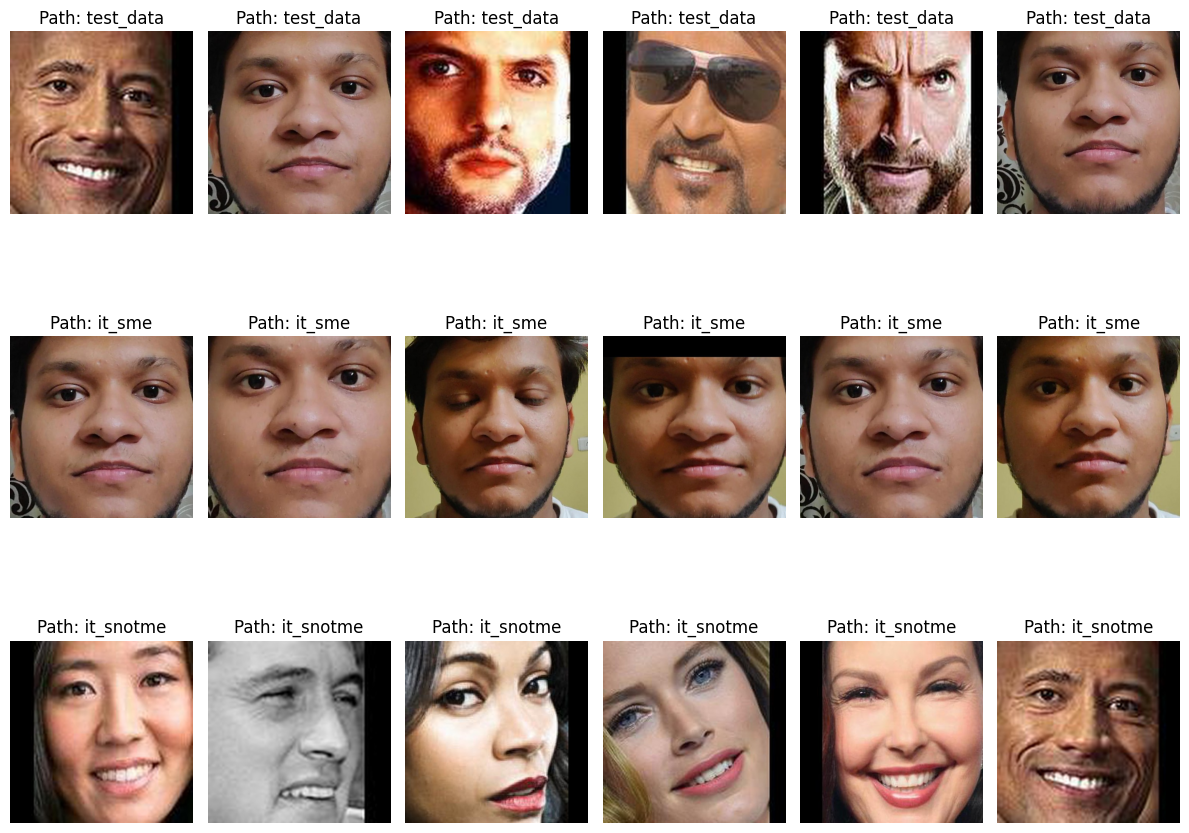

In [4]:
# Load each path images with 6 subplots for each path
fig, axes = plt.subplots(3, 6, figsize=(12, 10))
axes = axes.flatten()
for i, path in enumerate([IMAGES_PATH_TEST, IMAGES_PATH_TRAIN_ME, IMAGES_PATH_TRAIN_NOT_ME]):
    image_files = list(image_files_in_folder(path))
    for j in range(6):
        if j < len(image_files):
            image = face_recognition.load_image_file(image_files[j])
            axes[i*6 + j].imshow(image)
            axes[i*6 + j].set_title(f"Path: {path.name}")
            axes[i*6 + j].axis('off')
plt.tight_layout()
plt.show()


## Similarity search

Encoding test images...


100%|██████████| 362/362 [00:03<00:00, 93.03it/s] 


Encoding train (me) images...


100%|██████████| 736/736 [00:08<00:00, 91.71it/s]


Showing top 5 similar image pair(s).


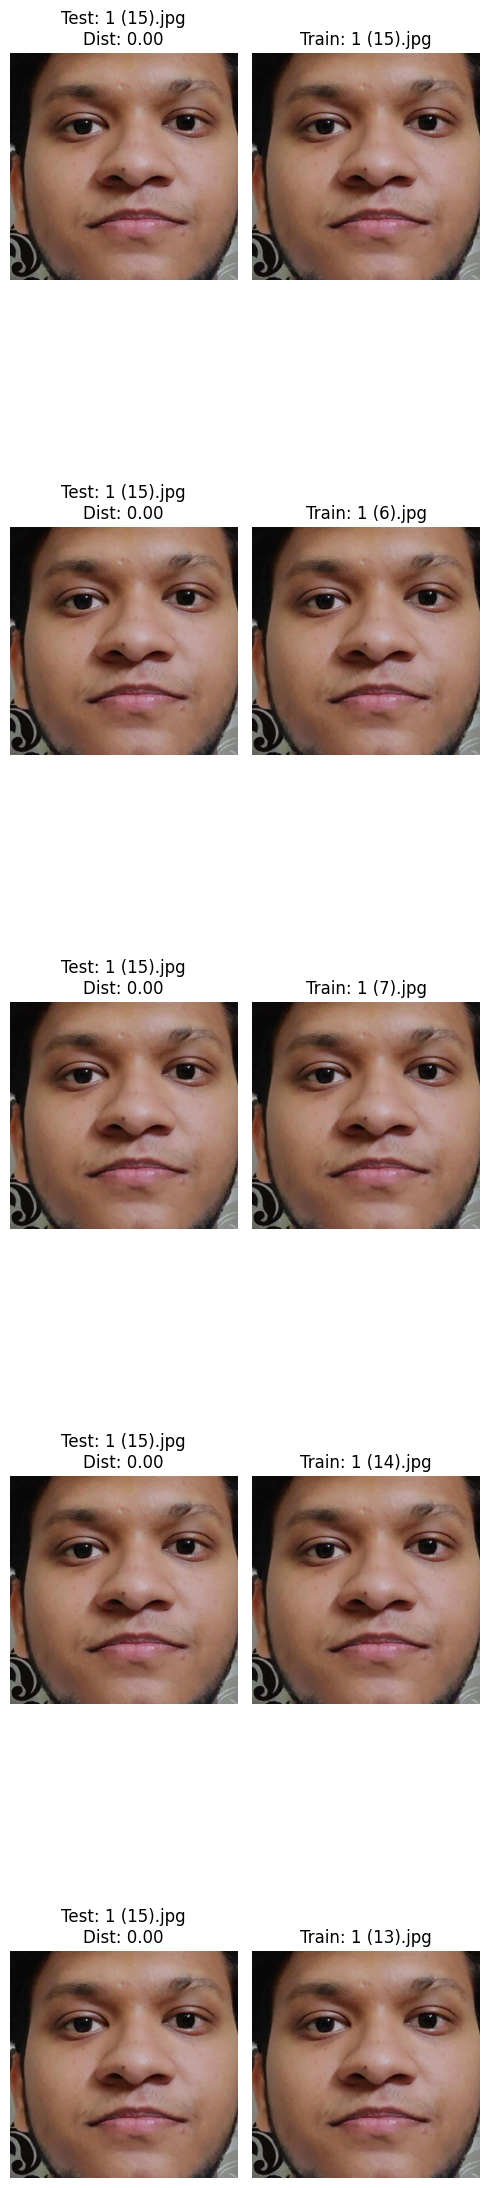

In [5]:
# Find similar images toward (IMAGES_PATH_TEST to IMAGES_PATH_TRAIN_ME)
test_image_files = list(image_files_in_folder(IMAGES_PATH_TEST))
train_me_image_files = list(image_files_in_folder(IMAGES_PATH_TRAIN_ME))

def encode_images(file_list, scale=0.25):
    """Encode face images at reduced scale using HOG (fast) detection."""
    encodings = []
    for f in tqdm(file_list):
        img = face_recognition.load_image_file(f)
        img_small = cv2.resize(img, (0, 0), fx=scale, fy=scale)
        locs = face_recognition.face_locations(img_small, model="hog")
        enc = face_recognition.face_encodings(img_small, known_face_locations=locs, model="small")
        encodings.append((f, enc[0] if enc else None))
    return encodings

print("Encoding test images...")
test_encodings = encode_images(test_image_files)

print("Encoding train (me) images...")
train_encodings = encode_images(train_me_image_files)

# Vectorized comparison: compare each test image against ALL train images at once
train_files = [f for f, enc in train_encodings if enc is not None]
train_encs  = [enc for _, enc in train_encodings if enc is not None]

similar_images = []
for test_image, test_enc in test_encodings:
    if test_enc is None:
        continue
    distances = face_recognition.face_distance(train_encs, test_enc)  # all at once
    for idx, dist in enumerate(distances):
        if dist < 0.6:
            similar_images.append((test_image, train_files[idx], dist))

# Keep only top 5 closest matches to avoid massive plots
similar_images = sorted(similar_images, key=lambda x: x[2])[:5]
print(f"Showing top {len(similar_images)} similar image pair(s).")

if not similar_images:
    print("No similar images found.")
else:
    fig, axes = plt.subplots(len(similar_images), 2, figsize=(5, 5 * len(similar_images)), squeeze=False)
    for i, (test_image, train_image, distance) in enumerate(similar_images):
        test_img = face_recognition.load_image_file(test_image)
        train_img = face_recognition.load_image_file(train_image)
        axes[i, 0].imshow(test_img)
        axes[i, 0].set_title(f"Test: {Path(test_image).name}\nDist: {distance:.2f}")
        axes[i, 0].axis('off')
        axes[i, 1].imshow(train_img)
        axes[i, 1].set_title(f"Train: {Path(train_image).name}")
        axes[i, 1].axis('off')
    plt.tight_layout()
    plt.show()


In [6]:
# add into dataframe the path of each path images
df["path"] = df["label"].apply(lambda x: IMAGES_PATH_TRAIN_ME if x == "its_me" else IMAGES_PATH_TRAIN_NOT_ME)
# show di rows long name in path column
df['path'] = df['path'].apply(lambda x: str(x))
df

,id,label,path
0,Robert Downey Jr_87.jpg,Robert Downey Jr,../../../database/face_data/train_data/train_d...
1,Lisa Kudrow_64.jpg,Lisa Kudrow,../../../database/face_data/train_data/train_d...
2,Ellen Degeneres_34.jpg,Ellen Degeneres,../../../database/face_data/train_data/train_d...
3,Billie Eilish_3.jpg,Billie Eilish,../../../database/face_data/train_data/train_d...
4,Hrithik Roshan_35.jpg,Hrithik Roshan,../../../database/face_data/train_data/train_d...
...,...,...,...
2557,Jessica Alba_90.jpg,Jessica Alba,../../../database/face_data/train_data/train_d...
2558,Elizabeth Olsen_27.jpg,Elizabeth Olsen,../../../database/face_data/train_data/train_d...
2559,Elizabeth Olsen_59.jpg,Elizabeth Olsen,../../../database/face_data/train_data/train_d...
2560,Henry Cavill_7.jpg,Henry Cavill,../../../database/face_data/train_data/train_d...
